---

### 🎓 **Professor**: Apostolos Filippas

### 📘 **Class**: AI Engineering

### 📋 **Homework 5**: RAG System for Fordham University

### 📅 **Due Date**: Day of Lecture 7, 11:59 PM

### Difficulty: ★★★★☆


**Note**: You are not allowed to share the contents of this notebook with anyone outside this class without written permission by the professor.

---

In this homework, you'll complete the RAG (Retrieval Augmented Generation) system you started building in Lecture 5. You will build an end-to-end pipeline that can answer questions about Fordham University using real data scraped from the Fordham website.

This is an open-ended assignment — there is no single right implementation, and you're encouraged to experiment with chunking strategies, embedding models, prompt design, and retrieval parameters to improve your system. **I will grade your system by testing it with specific questions that I know the answer to.**

---

## Instructions

- You may use ChatGPT, Claude, documentation, Stack Overflow, etc. When using external resources, briefly cite them in a comment.
- Your submission must include **pre-computed embeddings** and any other artifacts needed so that I can run your RAG system without recomputing anything expensive. Share it with us in a way that makes sense.
- Run all cells before submitting to ensure they work.

**Submission:**
1. Create a branch called `homework-5`
2. Commit and push your work (notebook + Streamlit app + saved embeddings/artifacts in `temp/`)
3. Create a PR and merge to main
4. Submit the `.ipynb` file on Blackboard

---

## Step 1: Load and Chunk the Fordham Website Data

In `data/fordham-website.zip` you'll find **~9,500 Markdown files** scraped from Fordham's website. Each file is one page — admissions info, program descriptions, faculty pages, financial aid, campus life, and more. The first line of every file is the **URL** of the page it was scraped from. The rest is the page content in Markdown.

Think about: chunk size, what to split on (paragraphs, headers, fixed length, etc.), whether chunks should overlap, and how to track which page each chunk came from.

In [1]:
# YOUR CODE HERE

# Loading the data

import zipfile
import pandas as pd

zipcontent = []
with zipfile.ZipFile("fordham-website.zip", "r") as fordham_zip:
    for files in fordham_zip.infolist():
        if files.is_dir():
            continue
        filename = files.filename
        with fordham_zip.open(files) as file:
            content = file.read().decode("utf-8", errors="ignore")
        zipcontent.append({"filename": filename,"content": content})
#print(zipcontent)
df_zipcontent = pd.DataFrame(zipcontent)
print(df_zipcontent.head())

                               filename  \
0                              index.md   
1                           research.md   
2                               ccel.md   
3  fordham-college-at-lincoln-center.md   
4                          academics.md   

                                             content  
0  https://www.fordham.edu/\n\n## Doing Good That...  
1  https://www.fordham.edu/research\n\nUncovering...  
2  https://www.fordham.edu/ccel\n\n# Center for C...  
3  https://www.fordham.edu/fordham-college-at-lin...  
4  https://www.fordham.edu/academics\n\n# Academi...  


In [ ]:
# Chunking The Documents

def chunk_document(text, chunk_size=1000, overlap=200): 
    text = " ".join(text.split())  # clean extra whitespace
    chunks = []
    start = 0
    while start < len(text):
        end = start + chunk_size
        chunk = text[start:end]
        chunks.append(chunk)
        start += chunk_size - overlap 
    return chunks


records = []
for _, row in df_zipcontent.iterrows():
    chunks = chunk_document(row["content"])
    for i, chunk in enumerate(chunks):
        records.append({"filename": row["filename"], "chunk_id": i, "chunk": chunk})

       
df_chunks = pd.DataFrame(records)
print(df_chunks.head(10))

                               filename  chunk_id  \
0                              index.md         0   
1                              index.md         1   
2                              index.md         2   
3                           research.md         0   
4                           research.md         1   
5                           research.md         2   
6                           research.md         3   
7                               ccel.md         0   
8                               ccel.md         1   
9  fordham-college-at-lincoln-center.md         0   

                                               chunk  
0  https://www.fordham.edu/ ## Doing Good That Be...  
1  : how Fordham’s students, faculty, and alumni ...  
2  1973, Title VI and Title VII of the Civil Righ...  
3  https://www.fordham.edu/research Uncovering th...  
4  , as seen in the open hiring process—no resume...  
5  der and a professional historian. BJHP is a Fo...  
6  elp from recent graduate Bea

---

## Step 2: Embed the Chunks

Turn each chunk into a vector so you can search over them. You can use a local model or an API model — your choice.

Once you've created your embeddings, **save them somewhere** so you (and I) don't have to redo this step. Save the chunk metadata too (text, source URL, etc.).

In [5]:
# YOUR CODE HERE

from sentence_transformers import SentenceTransformer
import numpy as np
import json

embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

chunk_texts = df_chunks["chunk"].tolist()
embeddings = embedding_model.encode(chunk_texts, show_progress_bar=True)

embeddings = np.array(embeddings)

print("Embedding shape:", embeddings.shape)

np.save("/Users/hema/ai-engineering-fordham/temp/embeddings.npy", embeddings)

df_chunks.to_json("/Users/hema/ai-engineering-fordham/temp/chunks_metadata.json", orient="records")

print("Embeddings and metadata saved.")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/1809 [00:00<?, ?it/s]

Embedding shape: (57868, 384)
Embeddings and metadata saved.


---

## Step 3: Retrieve

Build the **R** in RAG. Write a function that takes a question and returns the most relevant chunks. You can use semantic search, BM25, hybrid — whatever you think works best.

Test it on a few questions and eyeball whether the results make sense.

In [6]:
# YOUR CODE HERE
embeddings = np.load("/Users/hema/ai-engineering-fordham/temp/embeddings.npy")
df_chunks = pd.read_json("/Users/hema/ai-engineering-fordham/temp/chunks_metadata.json")

def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

def retrieve(question, k=5):
    q_embedding = embedding_model.encode(question)
    similarities = []
    for emb in embeddings:
        sim = cosine_similarity(q_embedding, emb)
        similarities.append(sim)
    similarities = np.array(similarities)
    top_k_idx = similarities.argsort()[-k:][::-1]
    results = df_chunks.iloc[top_k_idx]
    return results

In [8]:
# Testing Retrieval

test_q = "Where is Fordham's campus?"

results = retrieve(test_q)
for _, row in results.iterrows():
    print(row["chunk"][:300])
    print("-"*60)

campus, call 718-817-0907 or visit [Fordham Campus Dining online](http://fordham.campusdish.com/).
------------------------------------------------------------
it Us **Rose Hill Campus ** 441 E. Fordham Road McShane Campus Center, Suite 215 Bronx, NY 10458 **Lincoln Center Campus** 140 W. 62nd Street Suite 140 and 140A New York, NY 10023
------------------------------------------------------------
 classroom](/media/home/commonly-used-images/classroom-and-campus-life/Professor-lecturing-at-the-front-of-the-classroom.jpg) 70+ Undergraduate Degree Programs 130+ Graduate Degree Programs 25+ Accelerated Degree Options 8 Schools/Colleges ## 8 Schools. 3 Campuses. Fordham is a stepping stone to the
------------------------------------------------------------
classroom](/media/home/commonly-used-images/classroom-and-campus-life/Professor-lecturing-at-the-front-of-the-classroom.jpg) 70+ Undergraduate Degree Programs 130+ Graduate Degree Programs 25+ Accelerated Degree Options 8 Schools/College

---

## Step 4: Generate

Build the **G** in RAG. Write a function that takes a question and the retrieved chunks, builds a prompt, and calls an LLM to generate an answer.

Think about: how to structure the prompt, what the LLM should do when the context doesn't contain the answer, and which model to use.

In [23]:
# YOUR CODE HERE

from openai import OpenAI

client = OpenAI()

def generate_answer(question, retrieved_chunks):

    context = "\n\n".join(retrieved_chunks["chunk"].tolist())

    prompt = f"""Use ONLY the information in the context below. If the answer is not in the context, say:
"Cannot answer this because of insufficient information"

Context:
{context}

Question:
{question}
Answer:
"""
    response = client.chat.completions.create( model="gpt-4o-mini",
     messages=[{"role":"user","content":prompt}],
     temperature= 0) # to improve accuracy and minimize randomness)
    return response.choices[0].message.content

---

## Step 5: Wire it Together

Combine the previous steps into a single `rag(question)` function. Question in, answer out.

In [24]:
# YOUR CODE HERE

def rag(question, k=5):
    retrieved_chunks = retrieve(question, k)
    answer = generate_answer(question, retrieved_chunks)
    return answer

In [28]:
# Demonstrate your RAG system

demo_questions = [
    "What programs does the Gabelli School of Business offer?",
    "How do I apply for financial aid at Fordham?",
    "What is the tuition for undergraduate students?",
    "Tell me about Fordham's campus locations.",
    "What research opportunities are available for students?",
]

for q in demo_questions:
    print(f"Q: {q}")
    answer = rag(q)
    print(f"A: {answer}")
    print("-" * 80)

#### The model sometimes answers the last question and sometimes says insufficient information. 

Q: What programs does the Gabelli School of Business offer?
A: The Gabelli School of Business offers a wide-ranging business school program that includes a liberal arts core, a business core, a major and concentration, and electives. Specific details about the curriculum can be found in their course bulletin. Additionally, a key semester in the program is called the consulting challenge, where students take initial courses in finance, marketing, management, and business communications while working in teams assigned to companies.
--------------------------------------------------------------------------------
Q: How do I apply for financial aid at Fordham?
A: To apply for financial aid at Fordham, you should utilize the Financial Aid Online portal to view your awards, document status, and messages. Once your deposit is processed, you can also accept or decline your aid. Additionally, ensure that you have your official transcripts from all undergraduate institutions attended, including 

---

## Step 6: Evaluate Your RAG System

A working RAG system is great — but how do you know it's actually *good*? You can't improve what you can't measure. In this step you'll build an evaluation framework using concepts from Lecture 6.

There are two things to evaluate in a RAG system:
- **Retrieval quality**: Are you finding the right chunks?
- **Answer quality**: Is the generated answer correct and grounded in the context?

### Build a test set

Create a test set of at least **10 question-answer pairs**. For each pair, provide the question and the expected answer (look it up in the data). Cover a range of question types — factual, procedural, about specific programs, etc.

### Evaluate retrieval

For each question, check whether the retrieved chunks actually contain relevant information. You can do this manually or automatically (e.g., use an LLM to judge relevance). Compute **context relevance** — the fraction of retrieved chunks that are actually useful.

### Evaluate answers with LLM-as-judge

Use an LLM to evaluate your system's answers on two dimensions:

1. **Faithfulness**: Does the answer only use information from the retrieved context? (No hallucination)
2. **Correctness**: Is the answer factually correct compared to the expected answer?

Use **structured outputs** (Pydantic) to get consistent scores from the judge. A starting schema is provided below — feel free to modify it.

In [33]:
from pydantic import BaseModel, Field

from pydantic import BaseModel, Field
class RAGEvaluation(BaseModel):
    faithfulness_score: int = Field(..., ge=1, le=5)
    faithfulness_reasoning: str
    correctness_score: int = Field(..., ge=1, le=5)
    correctness_reasoning: str

In [34]:
# YOUR CODE HERE
# - Build your test set

test_set = [
    { "question": "Where is Fordham University located?",
        "expected_answer": "Fordham University has campuses in the Bronx, Manhattan, and Westchester County."},
    { "question": "What is the Gabelli School of Business?",
        "expected_answer": "The Gabelli School of Business is Fordham's business school offering undergraduate and graduate business programs."},
    {"question": "How can students apply for financial aid?",
        "expected_answer": "Students apply for financial aid by submitting the FAFSA and other required forms."},
    {"question": "Does Fordham offer research opportunities?",
        "expected_answer": "Fordham provides research opportunities for undergraduate and graduate students across many disciplines."},
    {"question": "What campuses does Fordham have?",
        "expected_answer": "Fordham has campuses in Rose Hill (Bronx), Lincoln Center (Manhattan), and Westchester."},
    {"question": "What undergraduate programs does Fordham offer?",
        "expected_answer": "Fordham offers a wide range of undergraduate programs across arts, sciences, business, and other disciplines."},
    {"question": "Is Fordham a Jesuit university?",
        "expected_answer": "Yes, Fordham University is a private Jesuit university."},
    {"question": "What student life opportunities exist at Fordham?",
        "expected_answer": "Fordham offers clubs, organizations, athletics, and campus events."},
    {"question": "Does Fordham have graduate programs?",
        "expected_answer": "Yes, Fordham offers many graduate and professional programs."},
    {"question": "Where can I find admissions information?",
        "expected_answer": "Admissions information is available on the Fordham admissions website."}
]

# - Evaluate retrieval quality (context relevance)

def evaluate_retrieval(question, k=5):
    retrieved = retrieve(question, k)
    relevant = 0
    for chunk in retrieved["chunk"]:
        if len(chunk) > 50:  # simple heuristic
            relevant += 1
    relevance_score = relevant / k
    return relevance_score
# - Evaluate answer quality with LLM-as-judge (faithfulness + correctness)

def judge_answer(question, expected_answer, model_answer):

    prompt = f"""
You are evaluating a RAG system.

Question:
{question}

Expected Answer:
{expected_answer}

Model Answer:
{model_answer}

Score the model answer from 1 to 5 for:

Faithfulness:
Does the answer rely only on the provided context?

Correctness:
Is the answer factually correct compared to the expected answer?

Return JSON with:
faithfulness_score
faithfulness_reasoning
correctness_score
correctness_reasoning
"""

    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role":"user","content":prompt}],
        temperature= 0 # to improve accuracy and minimize randomness.
    )
    return response.choices[0].message.content

results = []
for item in test_set:
    q = item["question"]
    expected = item["expected_answer"]
    model_answer = rag(q)
    retrieval_score = evaluate_retrieval(q)
    evaluation = judge_answer(q, expected, model_answer)
    results.append({
        "question": q,
        "retrieval_score": retrieval_score,
        "model_answer": model_answer,
        "evaluation": evaluation
    })
df_results = pd.DataFrame(results)
print(df_results.head())

                                     question  retrieval_score  \
0        Where is Fordham University located?              1.0   
1     What is the Gabelli School of Business?              0.8   
2   How can students apply for financial aid?              1.0   
3  Does Fordham offer research opportunities?              1.0   
4            What campuses does Fordham have?              1.0   

                                        model_answer  \
0  Fordham University is located at three campuse...   
1  The Gabelli School of Business is a business s...   
2  Students can apply for financial aid by comple...   
3  Yes, Fordham offers research opportunities, in...   
4  Fordham has the following campuses:\n- Fordham...   

                                          evaluation  
0  ```json\n{\n  "faithfulness_score": 5,\n  "fai...  
1  ```json\n{\n  "faithfulness_score": 4,\n  "fai...  
2  ```json\n{\n  "faithfulness_score": 4,\n  "fai...  
3  ```json\n{\n  "faithfulness_score": 4,\n  "

In [35]:
# - Summarize your results

faithfulness_scores = []
correctness_scores = []
for e in df_results["evaluation"]:
    cleaned = e.replace("```json", "").replace("```", "").strip()
    data = json.loads(cleaned)
    faithfulness_scores.append(data["faithfulness_score"])
    correctness_scores.append(data["correctness_score"])
df_results["faithfulness_score"] = faithfulness_scores
df_results["correctness_score"] = correctness_scores

avg_retrieval = df_results["retrieval_score"].mean()
avg_faithfulness = df_results["faithfulness_score"].mean()
avg_correctness = df_results["correctness_score"].mean()

print("Average Retrieval Relevance:", round(avg_retrieval,2))
print("Average Faithfulness Score:", round(avg_faithfulness,2))
print("Average Correctness Score:", round(avg_correctness,2))

Average Retrieval Relevance: 0.92
Average Faithfulness Score: 4.3
Average Correctness Score: 4.5


_The RAG system performed well overall on the evaluation set. The average retrieval relevance score was 0.92, indicating that most of the retrieved chunks contained useful information related to the question. The average faithfulness score was 4.3 out of 5, meaning the generated answers were generally grounded in the retrieved context with minimal hallucination. The average correctness score was 4.5 out of 5, suggesting that the system usually produced accurate responses, though some answers were slightly incomplete depending on the retrieved context. Overall, the system demonstrates effective retrieval and answer generation using the Fordham website data._

---

## Step 7: Build a Streamlit App

Your RAG system lives inside a notebook — that's great for development, but nobody is going to use a Jupyter notebook to ask questions about Fordham. Turn it into a web app using [Streamlit](https://docs.streamlit.io/).

Create a `.py` file (e.g., `scripts/fordham_rag_app.py`) that:
1. Lets the user type a question about Fordham
2. Runs your RAG pipeline
3. Displays the answer and the source pages used

**Getting started:**
- Install: `uv pip install streamlit`
- Run: `streamlit run scripts/fordham_rag_app.py`

**Tip**: Use `@st.cache_resource` to avoid reloading embeddings on every interaction.

**Include a screenshot of your working app below.**

*Paste your screenshot here*

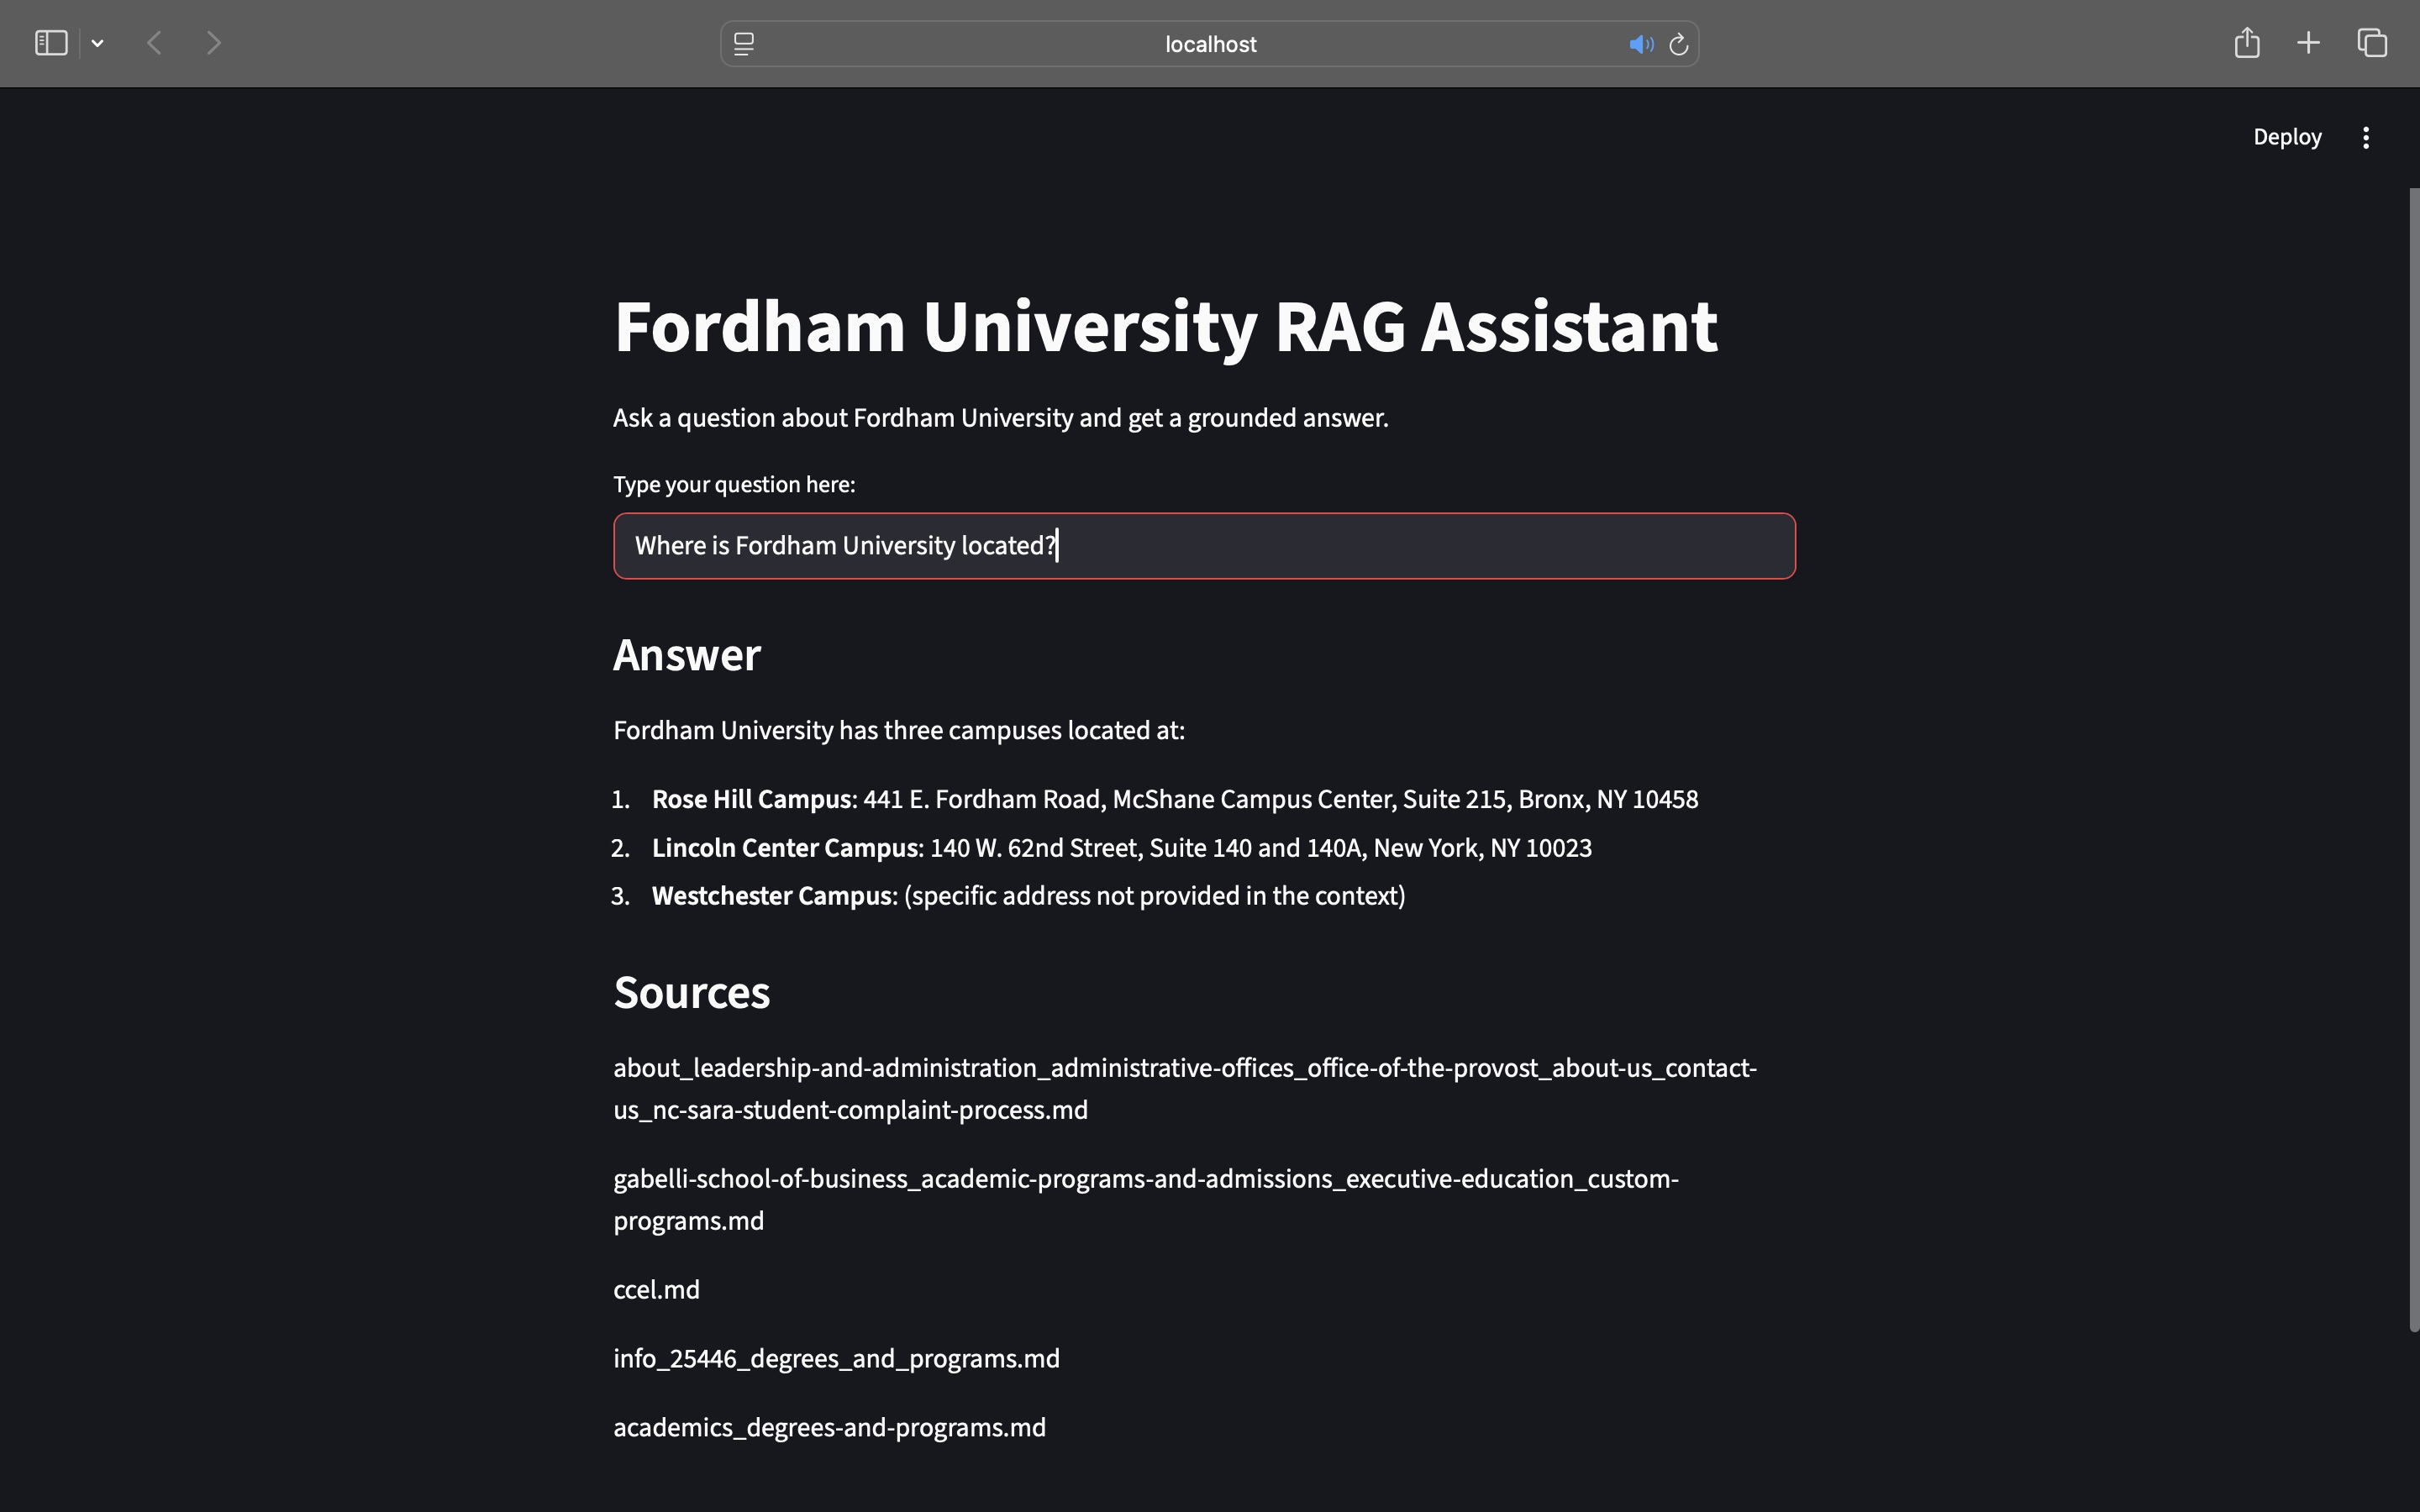

In [38]:
from IPython.display import Image
Image(filename='/Users/hema/ai-engineering-fordham/AIHW5streamlit.jpg', width=500)

---

## Step 8: How to Run Your System

Fill in the details below so that I can run and test your RAG system.

| Item | Your Answer |
|------|-------------|
| **Embedding model used** | all-MiniLM-L6-v2 (SentenceTransformers)|
| **LLM used for generation** | gpt-4o-mini|
| **LLM used for evaluation (judge)** | gpt-4o-mini|
| **Saved artifacts** | `embeddings.npy`, `chunks_metadata.json` |
| **How to start the Streamlit app** | `streamlit run scripts/fordham_rag_app.py` |
| **Any API keys or env vars needed** | `OPENAI_API_KEY` in `.env`) |
| **Anything else I should know** | |

---

## Bonus: Experiment and Improve

Now that you have a working RAG system *and* a way to measure its quality, try to improve it. Use your evaluation framework to measure the impact of changes.

Ideas: different chunk sizes, different embedding models, hybrid search, better prompts, reranking, query rewriting. Document what you tried and show before/after evaluation scores.

In [ ]:
# YOUR CODE HERE

---

## Git Submission

- [ ] Create a new branch called `homework-5`
- [ ] Commit your work (notebook + Streamlit app + saved artifacts in `temp/`)
- [ ] Push to GitHub
- [ ] Create a Pull Request and merge to main
- [ ] Submit the `.ipynb` file on Blackboard